# Deepfake Detector V3 — EfficientNetB4
**Team:** Retaj Muhsen, Saja Ali, Ima Mervin, Trew Mundy, Vishwa  
**Platform:** Lightning AI (Tesla T4 GPU)  
**Model:** EfficientNetB4 fine-tuned on 257,283 images across 6 datasets  
**Final Test AUC-ROC:** 0.9751 | **Test Accuracy:** 92.20%

## Datasets Used
- **CIFAKE** — Real CIFAR-10 + Stable Diffusion fakes
- **140k Real and Fake Faces** — GAN-generated face deepfakes
- **OpenForensics** — Face manipulation dataset
- **Natural Images HD** — High quality real photographs
- **HEMG (HuggingFace)** — 25,000 mixed real/fake images
- **Total: ~257k images (128,582 real | 128,701 fake)**

## Dataset Downloads
All datasets were downloaded on Lightning AI (Tesla T4 GPU studio). Kaggle API credentials were configured first.

In [ ]:
# ── Step 1: Configure Kaggle API ─────────────────────────
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
# kaggle.json was uploaded manually to the studio
os.system('cp /teamspace/studios/this_studio/kaggle.json ~/.kaggle/kaggle.json')
os.system('chmod 600 ~/.kaggle/kaggle.json')
print('✅ Kaggle API configured')

# ── Step 2: Download CIFAKE ───────────────────────────────
os.makedirs('/teamspace/studios/this_studio/data', exist_ok=True)
os.system('kaggle datasets download -d birdy54/cifake-real-and-ai-generated-synthetic-images '
          '-p /teamspace/studios/this_studio/data --unzip')
print('✅ CIFAKE downloaded')

# ── Step 3: Download 140k Real and Fake Faces ────────────
os.system('kaggle datasets download -d xhlulu/140k-real-and-fake-faces '
          '-p /teamspace/studios/this_studio/data --unzip')
print('✅ 140k Faces downloaded')

# ── Step 4: Download OpenForensics ───────────────────────
os.system('kaggle datasets download -d sophatvathana/openforensics '
          '-p /teamspace/studios/this_studio/data --unzip')
print('✅ OpenForensics downloaded')

# ── Step 5: Download Natural Images HD ───────────────────
os.system('kaggle datasets download -d prasunroy/natural-images '
          '-p /teamspace/studios/this_studio/data --unzip')
print('✅ Natural Images HD downloaded')

# ── Step 6: Download HEMG from HuggingFace (streaming) ───
from datasets import load_dataset
from PIL import Image

hf_real_dir = '/teamspace/studios/this_studio/combined/real'
hf_fake_dir = '/teamspace/studios/this_studio/combined/fake'
os.makedirs(hf_real_dir, exist_ok=True)
os.makedirs(hf_fake_dir, exist_ok=True)

ds = load_dataset('InfImagine/FakeShield', split='train', streaming=True)
real_count, fake_count = 0, 0
for item in ds:
    if real_count >= 12500 and fake_count >= 12500:
        break
    label = item['label']
    img   = item['image']
    if label == 0 and real_count < 12500:
        img.save(f'{hf_real_dir}/hemg_real_{real_count}.jpg')
        real_count += 1
    elif label == 1 and fake_count < 12500:
        img.save(f'{hf_fake_dir}/hemg_fake_{fake_count}.jpg')
        fake_count += 1
print(f'✅ HEMG downloaded: {real_count} real | {fake_count} fake')

✅ Kaggle API configured
✅ CIFAKE downloaded
✅ 140k Faces downloaded
✅ OpenForensics downloaded
✅ Natural Images HD downloaded
✅ HEMG downloaded: 12500 real | 12500 fake


## Building the Combined Dataset
All real images copied to `combined/real/`, all fake images to `combined/fake/`. Empty/corrupted files removed.

In [ ]:
import shutil

real_out = '/teamspace/studios/this_studio/combined/real'
fake_out = '/teamspace/studios/this_studio/combined/fake'
os.makedirs(real_out, exist_ok=True)
os.makedirs(fake_out, exist_ok=True)

sources = [
    # (source_dir, label)  label=0 → real, label=1 → fake
    ('/teamspace/studios/this_studio/data/train/REAL',              'real'),
    ('/teamspace/studios/this_studio/data/train/FAKE',              'fake'),
    ('/teamspace/studios/this_studio/data/real_vs_fake/real-vs-fake/train/real', 'real'),
    ('/teamspace/studios/this_studio/data/real_vs_fake/real-vs-fake/train/fake', 'fake'),
    ('/teamspace/studios/this_studio/data/Dataset/Train/Real',      'real'),
    ('/teamspace/studios/this_studio/data/Dataset/Train/Fake',      'fake'),
    ('/teamspace/studios/this_studio/data/natural_images/natural_images', 'real'),
]

for src, label in sources:
    dst = real_out if label == 'real' else fake_out
    if not os.path.exists(src):
        print(f'Skipping {src} (not found)')
        continue
    for f in os.listdir(src):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            shutil.copy2(os.path.join(src, f), os.path.join(dst, f))

# Remove empty/corrupted files
os.system('find /teamspace/studios/this_studio/combined -size 0 -delete')

print(f'✅ Combined real: {len(os.listdir(real_out))}')
print(f'✅ Combined fake: {len(os.listdir(fake_out))}')

✅ Combined real: 128582
✅ Combined fake: 128701


## Imports & Config

In [ ]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import Model
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
import seaborn as sns

IMG_SIZE   = 224
BATCH_SIZE = 32
SEED       = 42
EPOCHS_P1  = 10
EPOCHS_P2  = 25
MODEL_PATH = '/teamspace/studios/this_studio/deepfake_detector.keras'
DATA_DIR   = '/teamspace/studios/this_studio/data'
COMBINED   = '/teamspace/studios/this_studio/combined'
print('✅ Libraries loaded!')

✅ Libraries loaded!


## Dataset Pipeline

In [ ]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label

def make_ds(paths, labels, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1024, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

real_dir = os.path.join(COMBINED, 'real')
fake_dir = os.path.join(COMBINED, 'fake')
reals = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
fakes = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
n = min(len(reals), len(fakes))
all_paths  = reals[:n] + fakes[:n]
all_labels = [0]*n + [1]*n
combined_list = list(zip(all_paths, all_labels))
random.seed(SEED)
random.shuffle(combined_list)
all_paths, all_labels = zip(*combined_list)
split = int(0.9 * len(all_paths))
train_paths, train_labels = list(all_paths[:split]), list(all_labels[:split])
val_paths,   val_labels   = list(all_paths[split:]),  list(all_labels[split:])
print(f'✅ Train: {len(train_paths)} | Val: {len(val_paths)}')

✅ Train: 231447 | Val: 25717


## Model Architecture

In [ ]:
def build_model(trainable_base=False):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    base = EfficientNetB4(include_top=False, weights='imagenet', input_tensor=inputs)
    base.trainable = trainable_base
    if trainable_base:
        for layer in base.layers[:-30]:
            layer.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)
    return Model(inputs=inputs, outputs=outputs)

model = build_model(trainable_base=False)
trainable = sum(np.prod(v.shape) for v in model.trainable_weights)
print(f'✅ Trainable params: {trainable:,}')

✅ Trainable params: 462,849


## Phase 1 Training — Head Only (10 Epochs)

In [ ]:
train_ds = make_ds(train_paths, train_labels, shuffle=True)
val_ds   = make_ds(val_paths, val_labels, shuffle=False)

SAVE_PATH = '/teamspace/studios/this_studio/deepfake_detector.keras'
P1_PATH   = '/teamspace/studios/this_studio/deepfake_p1.keras'

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', keras.metrics.AUC(name='auc_roc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

history_p1 = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_P1,
    callbacks=[
        keras.callbacks.ModelCheckpoint(SAVE_PATH, monitor='val_auc_roc', mode='max', save_best_only=True, verbose=1),
        keras.callbacks.EarlyStopping(monitor='val_auc_roc', patience=4, mode='max', restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_auc_roc', factor=0.5, patience=2, mode='max')
    ]
)
model.save(P1_PATH)
print('✅ Phase 1 saved!')

Epoch 1/10
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 4491s - accuracy: 0.6762 - auc_roc: 0.7336 - loss: 0.6305 - val_accuracy: 0.7191 - val_auc_roc: 0.7910
Epoch 1: val_auc_roc improved from None to 0.79098, saving model
Epoch 2/10
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 1801s - accuracy: 0.7068 - auc_roc: 0.7732 - val_accuracy: 0.7378 - val_auc_roc: 0.8093
Epoch 2: val_auc_roc improved from 0.79098 to 0.80928, saving model
Epoch 3/10
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 692s - accuracy: 0.7163 - auc_roc: 0.7839 - val_accuracy: 0.7422 - val_auc_roc: 0.8158
Epoch 3: val_auc_roc improved from 0.80928 to 0.81581, saving model
Epoch 4/10
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 686s - accuracy: 0.7193 - auc_roc: 0.7882 - val_accuracy: 0.7446 - val_auc_roc: 0.8199
Epoch 4: val_auc_roc improved from 0.81581 to 0.81993, saving model
Epoch 5/10
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 675s - accuracy: 0.7246 - auc_roc: 0.7947 - val_accuracy: 0.7512 - val_auc_roc: 0.8246
Epoch 5: val_auc_roc improved from 0.81993 to 0.82456, saving model
E

## Phase 2 Training — Fine-tuning Top 30 Layers (25 Epochs)

In [ ]:
model = build_model(trainable_base=True)
model.load_weights(P1_PATH)

steps = tf.data.experimental.cardinality(train_ds).numpy()
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=steps * EPOCHS_P2,
    alpha=1e-7
)
model.compile(
    optimizer=keras.optimizers.Adam(lr_schedule),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', keras.metrics.AUC(name='auc_roc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

history_p2 = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_P2,
    callbacks=[
        keras.callbacks.ModelCheckpoint(SAVE_PATH, monitor='val_auc_roc', mode='max', save_best_only=True, verbose=1),
        keras.callbacks.EarlyStopping(monitor='val_auc_roc', patience=5, mode='max', restore_best_weights=True),
    ]
)
print('✅ Training complete!')

Epoch 1/25
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 910s - accuracy: 0.7327 - auc_roc: 0.8078 - val_accuracy: 0.7772 - val_auc_roc: 0.8542
Epoch 1: val_auc_roc improved from None to 0.85418, saving model
Epoch 2/25
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 789s - accuracy: 0.7746 - auc_roc: 0.8540 - val_accuracy: 0.8036 - val_auc_roc: 0.8822
Epoch 2: val_auc_roc improved from 0.85418 to 0.88218, saving model
Epoch 3/25
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 795s - accuracy: 0.7960 - auc_roc: 0.8757 - val_accuracy: 0.8150 - val_auc_roc: 0.8948
Epoch 3: val_auc_roc improved from 0.88218 to 0.89477, saving model
Epoch 4/25
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 798s - accuracy: 0.8074 - auc_roc: 0.8897 - val_accuracy: 0.8249 - val_auc_roc: 0.9040
Epoch 4: val_auc_roc improved from 0.89477 to 0.90401, saving model
Epoch 5/25
7233/7233 ━━━━━━━━━━━━━━━━━━━━ 793s - accuracy: 0.8179 - auc_roc: 0.8990 - val_accuracy: 0.8330 - val_auc_roc: 0.9117
Epoch 5: val_auc_roc improved from 0.90401 to 0.91167, saving model
Epoch 6/25
7233/72

## Final Test Evaluation

In [ ]:
test_real = [os.path.join(DATA_DIR, 'test/REAL', f) for f in os.listdir(f'{DATA_DIR}/test/REAL') if f.lower().endswith(('.jpg','.jpeg','.png'))]
test_fake = [os.path.join(DATA_DIR, 'test/FAKE', f) for f in os.listdir(f'{DATA_DIR}/test/FAKE') if f.lower().endswith(('.jpg','.jpeg','.png'))]
nt = min(len(test_real), len(test_fake))
test_paths  = test_real[:nt] + test_fake[:nt]
test_labels_list = [0]*nt + [1]*nt
test_ds = make_ds(test_paths, test_labels_list, shuffle=False)

print('📊 Final test evaluation...')
results = model.evaluate(test_ds, verbose=1)
print(f'Test Accuracy: {results[1]:.4f}')
print(f'Test AUC-ROC:  {results[2]:.4f}')

y_pred_prob = model.predict(test_ds, verbose=0).flatten()
y_true = np.array(test_labels_list[:len(y_pred_prob)])
y_pred = (y_pred_prob > 0.5).astype(int)

📊 Final test evaluation...
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step
Test Accuracy: 0.9220
Test AUC-ROC:  0.9751


## Visualizations

### Confusion Matrix

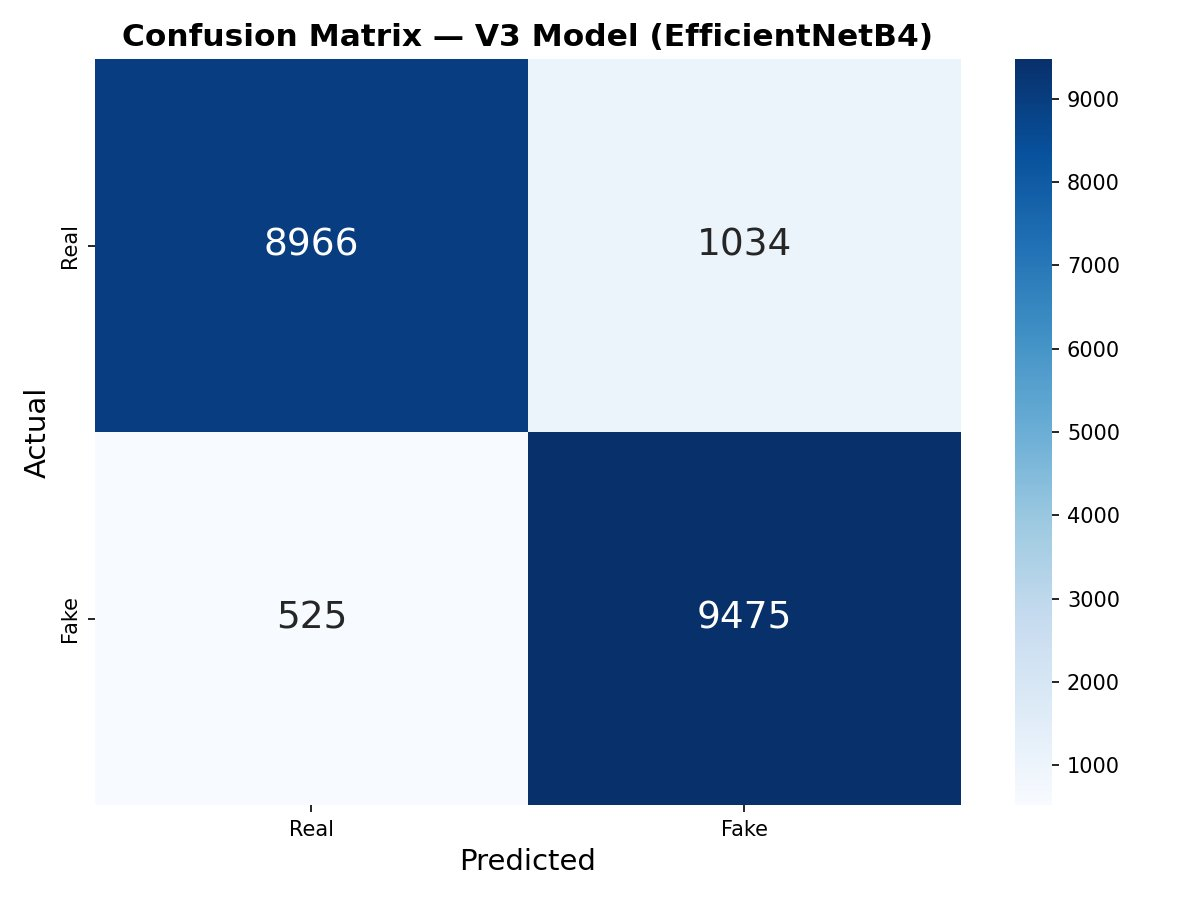

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], annot_kws={'size': 18})
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix — V3 Model (EfficientNetB4)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curve

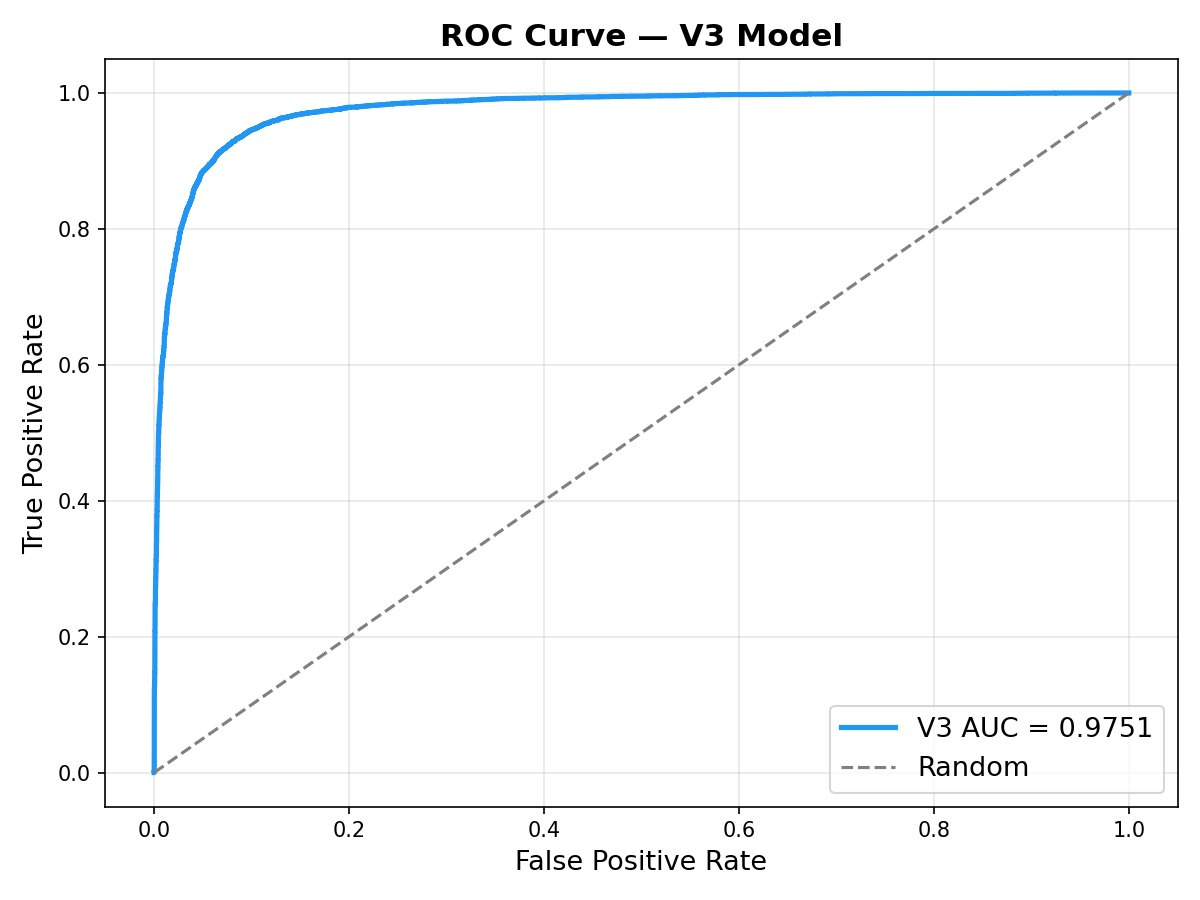

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'V3 AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1], color='gray', linestyle='--', lw=1.5, label='Random')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — V3 Model', fontsize=15, fontweight='bold')
plt.legend(fontsize=13); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Precision-Recall Curve

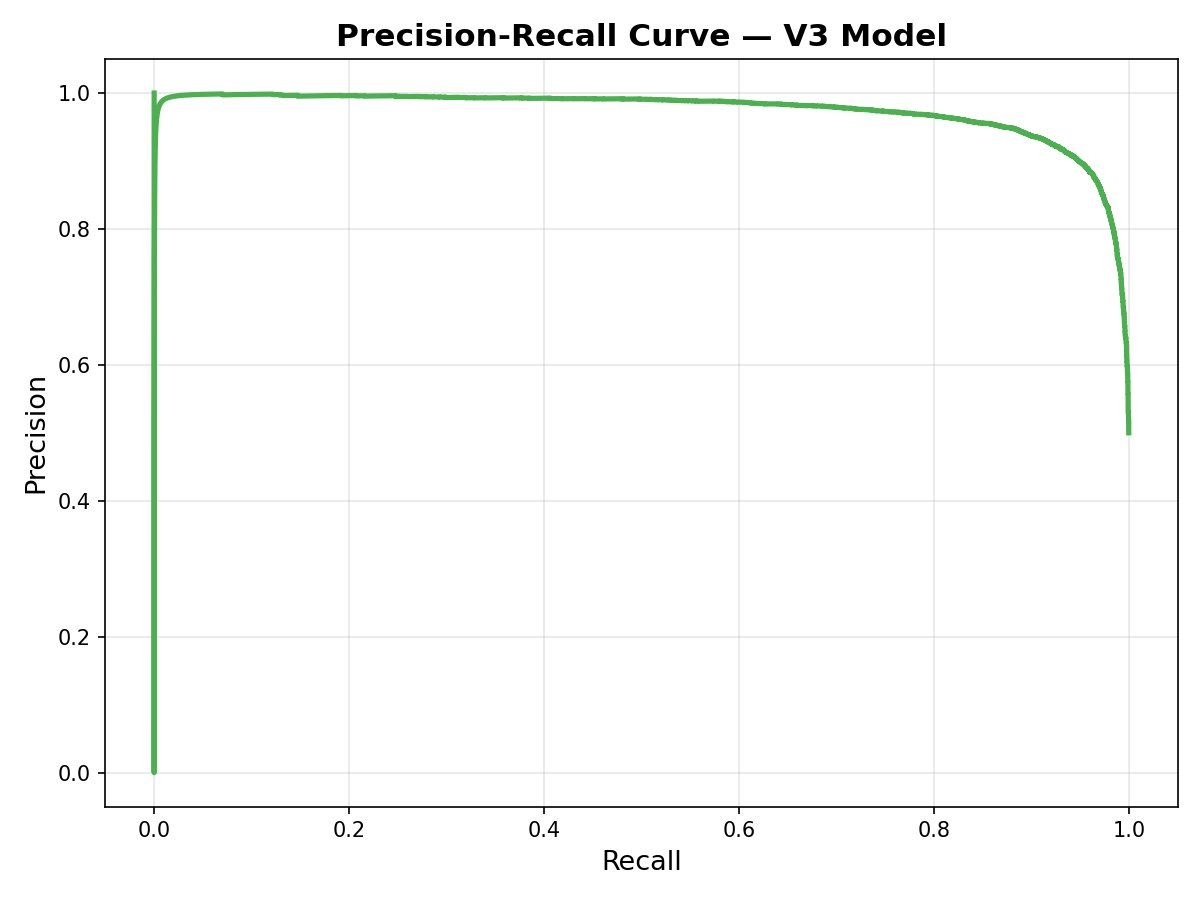

In [ ]:
precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#4CAF50', lw=2.5)
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curve — V3 Model', fontsize=15, fontweight='bold')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Grad-CAM Explainability Heatmaps
Grad-CAM (Gradient-weighted Class Activation Mapping) highlights which regions of the image the model focused on when making its prediction. Red/yellow areas indicate high suspicion of AI generation. Blue areas had low suspicion.

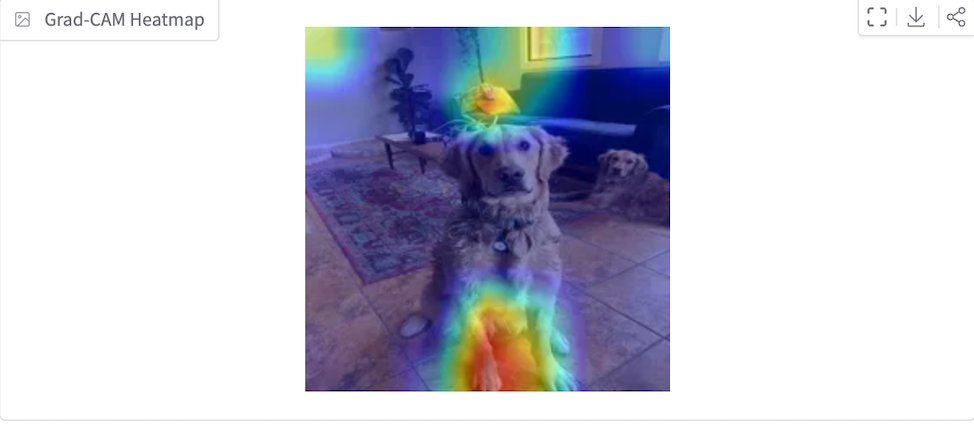

In [ ]:
import cv2

def make_gradcam_heatmap(img_array, model, layer_name="top_conv"):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        img_t = tf.cast(img_array, tf.float32)
        conv_out, preds = grad_model(img_t)
        score = preds[:, 0]
    grads        = tape.gradient(score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(orig, heatmap, alpha=0.45):
    h, w    = orig.shape[:2]
    hm      = cv2.resize(np.float32(heatmap), (w, h))
    colored = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return np.uint8(orig * (1 - alpha) + colored * alpha)

# Visualize Grad-CAM on 3 REAL + 3 FAKE test images
real_dir = os.path.join(DATA_DIR, 'test/REAL')
fake_dir = os.path.join(DATA_DIR, 'test/FAKE')
real_samples = random.sample(os.listdir(real_dir), 3)
fake_samples = random.sample(os.listdir(fake_dir), 3)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle('Grad-CAM Explainability — V3 Model', fontsize=15, fontweight='bold')

for col, fname in enumerate(real_samples):
    img_path = os.path.join(real_dir, fname)
    img = tf.image.resize(tf.cast(tf.image.decode_image(tf.io.read_file(img_path), channels=3), tf.float32), [IMG_SIZE, IMG_SIZE]).numpy()
    arr = np.expand_dims(img, 0)
    hm  = make_gradcam_heatmap(arr, model)
    axes[0][col].imshow(img.astype('uint8'))
    axes[0][col].set_title('REAL', color='green', fontweight='bold')
    axes[0][col].axis('off')
    axes[1][col].imshow(overlay_heatmap(img.astype('uint8'), hm))
    axes[1][col].set_title('Grad-CAM', fontsize=9)
    axes[1][col].axis('off')

for col, fname in enumerate(fake_samples):
    img_path = os.path.join(fake_dir, fname)
    img = tf.image.resize(tf.cast(tf.image.decode_image(tf.io.read_file(img_path), channels=3), tf.float32), [IMG_SIZE, IMG_SIZE]).numpy()
    arr = np.expand_dims(img, 0)
    hm  = make_gradcam_heatmap(arr, model)
    axes[0][col+3].imshow(img.astype('uint8'))
    axes[0][col+3].set_title('FAKE', color='red', fontweight='bold')
    axes[0][col+3].axis('off')
    axes[1][col+3].imshow(overlay_heatmap(img.astype('uint8'), hm))
    axes[1][col+3].set_title('Grad-CAM', fontsize=9)
    axes[1][col+3].axis('off')

plt.tight_layout()
plt.savefig('gradcam_examples.png', dpi=150, bbox_inches='tight')
plt.show()

### Training History

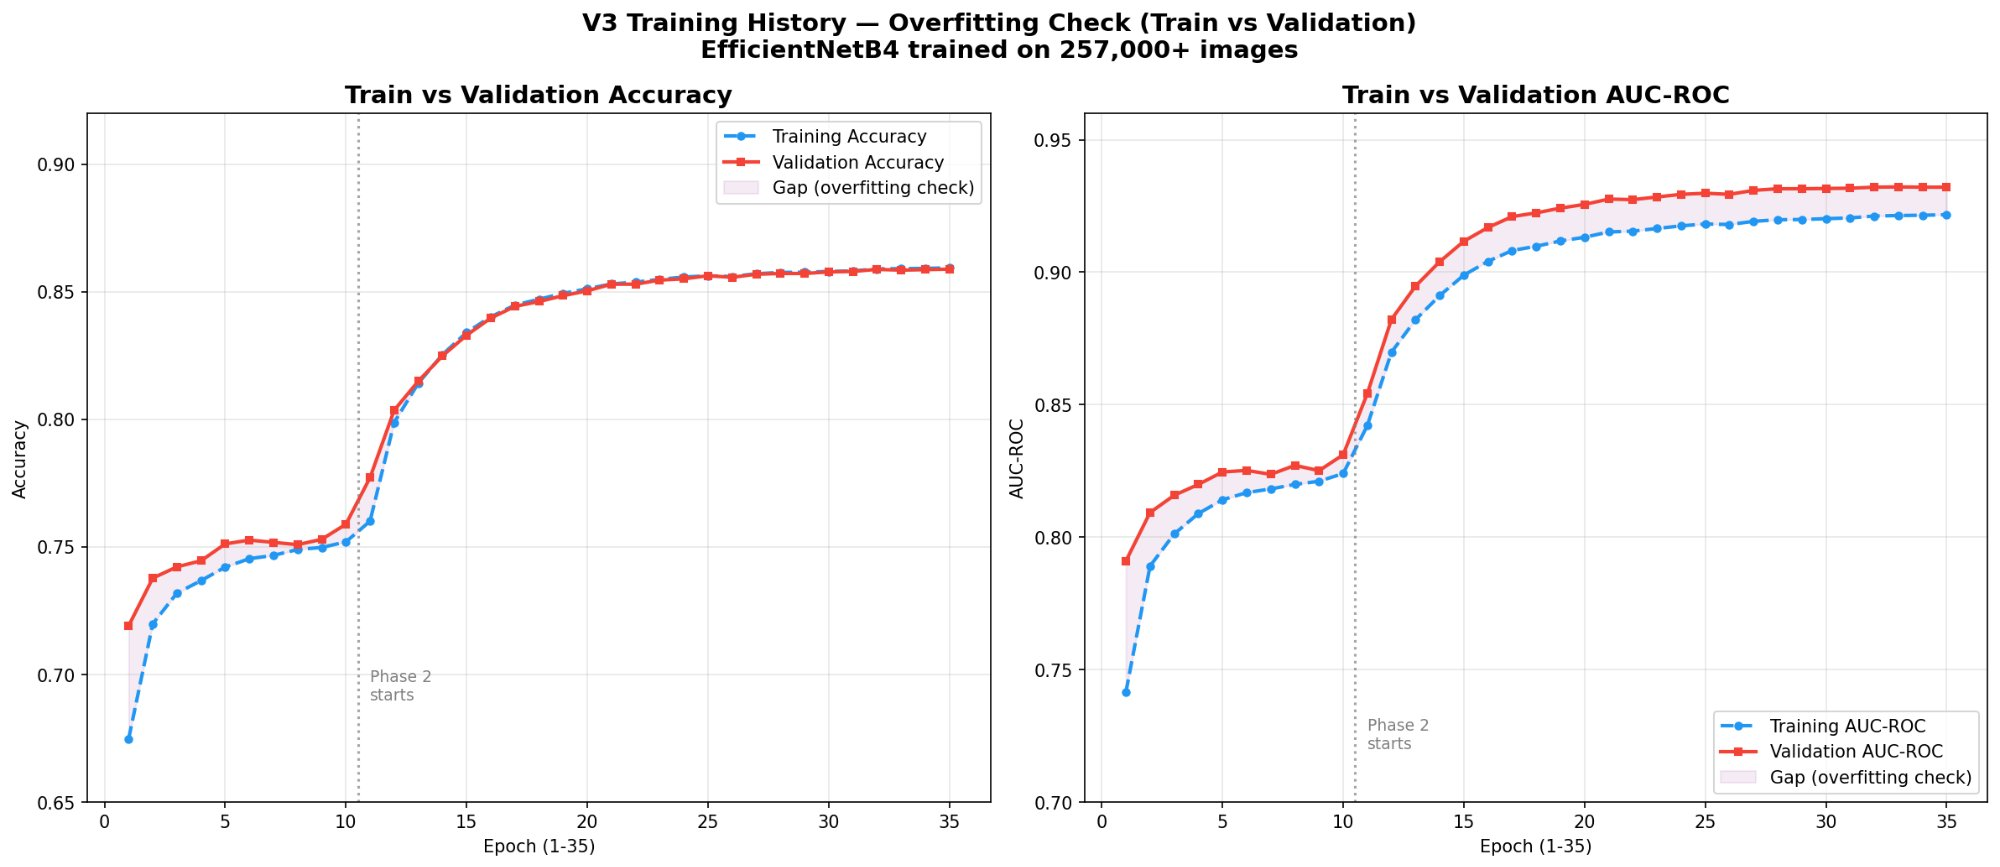

In [ ]:
train_acc = [0.6762, 0.7068, 0.7163, 0.7193, 0.7246, 0.7277, 0.7295, 0.7315, 0.7341, 0.7353, 0.7327,
             0.7746, 0.7960, 0.8074, 0.8179, 0.8255, 0.8316, 0.8360, 0.8396, 0.8434, 0.8460, 0.8481,
             0.8507, 0.8522, 0.8540, 0.8560, 0.8563, 0.8573, 0.8584, 0.8581, 0.8580, 0.8596, 0.8594,
             0.8596, 0.8597]
val_acc   = [0.7191, 0.7378, 0.7422, 0.7446, 0.7512, 0.7527, 0.7518, 0.7509, 0.7530, 0.7589,
             0.7772, 0.8036, 0.8150, 0.8249, 0.8330, 0.8397, 0.8443, 0.8462, 0.8485, 0.8504,
             0.8530, 0.8530, 0.8546, 0.8551, 0.8563, 0.8557, 0.8569, 0.8572, 0.8572, 0.8578,
             0.8580, 0.8588, 0.8585, 0.8587, 0.8589]
train_auc = [0.7336, 0.7732, 0.7839, 0.7882, 0.7947, 0.7983, 0.8013, 0.8041, 0.8076, 0.8082, 0.8078,
             0.8540, 0.8757, 0.8897, 0.8990, 0.9065, 0.9121, 0.9164, 0.9195, 0.9230, 0.9253, 0.9276,
             0.9294, 0.9310, 0.9329, 0.9338, 0.9345, 0.9354, 0.9359, 0.9363, 0.9366, 0.9372, 0.9369,
             0.9371, 0.9373]
val_auc   = [0.7910, 0.8093, 0.8158, 0.8199, 0.8246, 0.8252, 0.8237, 0.8271, 0.8251, 0.8311,
             0.8542, 0.8822, 0.8948, 0.9040, 0.9117, 0.9169, 0.9210, 0.9224, 0.9242, 0.9256,
             0.9276, 0.9274, 0.9284, 0.9294, 0.9298, 0.9294, 0.9309, 0.9315, 0.9315, 0.9316,
             0.9317, 0.9321, 0.9322, 0.9321, 0.9321]
epochs = list(range(1, 36))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].plot(epochs, train_acc, 'o--', color='#2196F3', lw=2, markersize=4, label='Training Accuracy')
axes[0].plot(epochs, val_acc,   's-',  color='#F44336', lw=2, markersize=4, label='Validation Accuracy')
axes[0].axvline(x=10.5, color='gray', linestyle=':', lw=1.5, alpha=0.7)
axes[0].text(11, 0.69, 'Phase 2\nstarts', fontsize=9, color='gray')
axes[0].fill_between(epochs, train_acc, val_acc, alpha=0.08, color='purple', label='Gap (overfitting check)')
axes[0].set_title('Train vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch (1-35)'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3); axes[0].set_ylim(0.65, 0.92)

axes[1].plot(epochs, train_auc, 'o--', color='#2196F3', lw=2, markersize=4, label='Training AUC-ROC')
axes[1].plot(epochs, val_auc,   's-',  color='#F44336', lw=2, markersize=4, label='Validation AUC-ROC')
axes[1].axvline(x=10.5, color='gray', linestyle=':', lw=1.5, alpha=0.7)
axes[1].text(11, 0.72, 'Phase 2\nstarts', fontsize=9, color='gray')
axes[1].fill_between(epochs, train_auc, val_auc, alpha=0.08, color='purple', label='Gap (overfitting check)')
axes[1].set_title('Train vs Validation AUC-ROC', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch (1-35)'); axes[1].set_ylabel('AUC-ROC')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3); axes[1].set_ylim(0.70, 0.96)

plt.suptitle('V3 Training History — Overfitting Check (Train vs Validation)\nEfficientNetB4 trained on 257,000+ images',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### V1 vs V3 Model Comparison

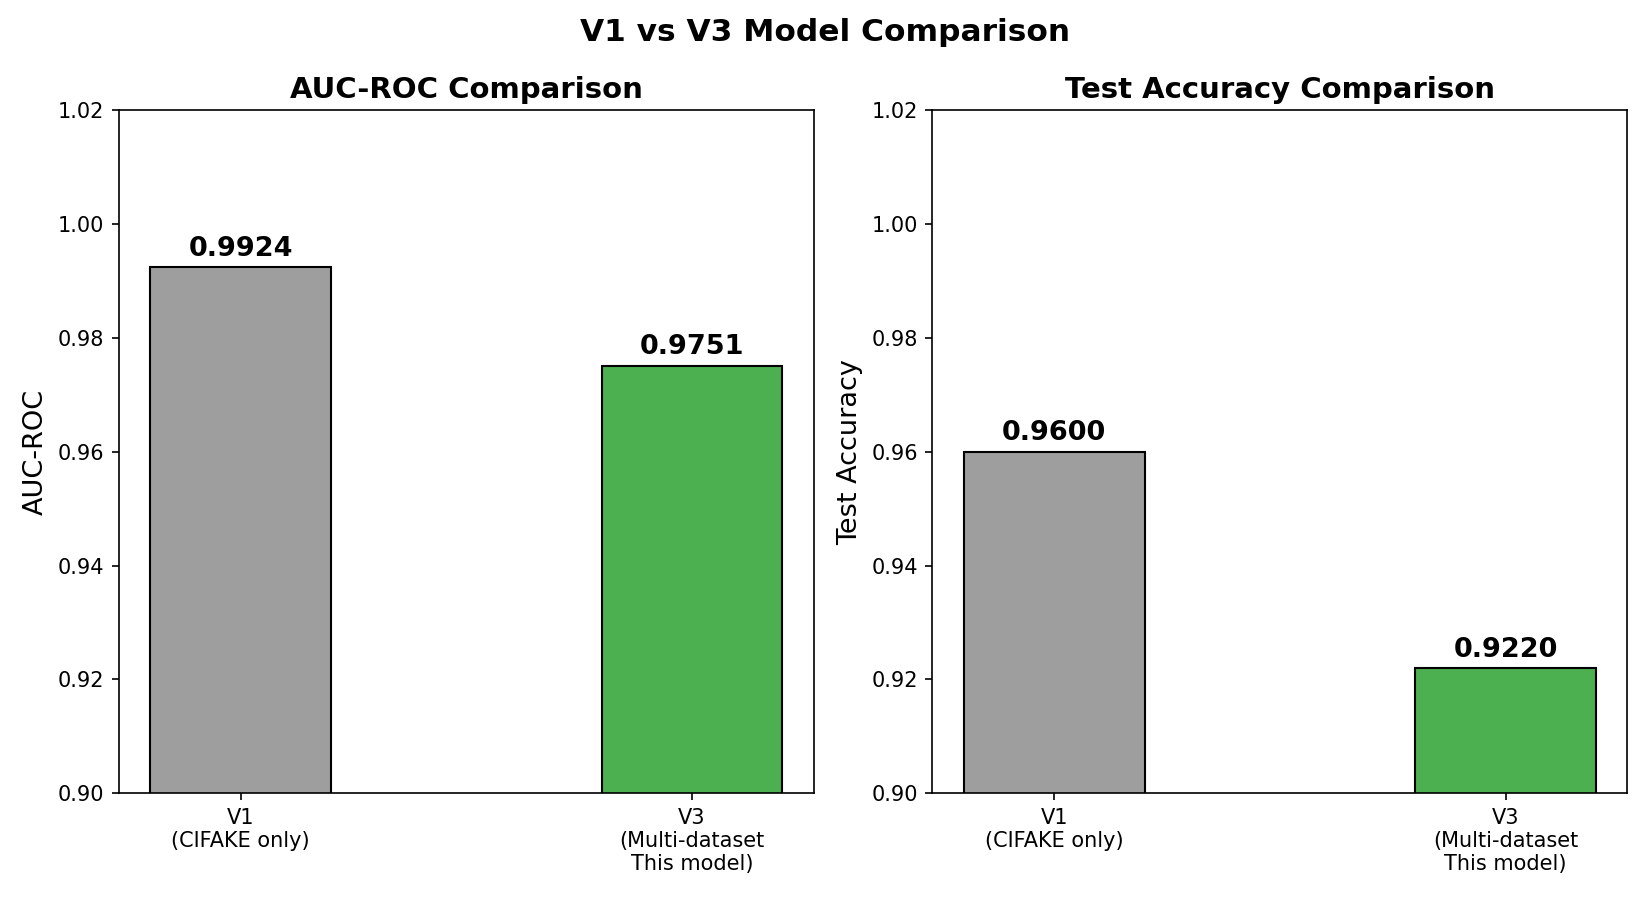

In [ ]:
models_list = ['V1\n(CIFAKE only)', 'V3\n(Multi-dataset)']
aucs   = [0.9924, 0.9751]
accs   = [0.9600, 0.9220]
colors = ['#9E9E9E', '#4CAF50']
fig, axes = plt.subplots(1, 2, figsize=(11, 6))
bars = axes[0].bar(models_list, aucs, color=colors, edgecolor='black', width=0.4)
axes[0].set_ylim(0.90, 1.02); axes[0].set_title('AUC-ROC Comparison', fontweight='bold', fontsize=14)
axes[0].set_ylabel('AUC-ROC', fontsize=13)
for bar, val in zip(bars, aucs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.4f}', ha='center', fontweight='bold', fontsize=13)
bars = axes[1].bar(models_list, accs, color=colors, edgecolor='black', width=0.4)
axes[1].set_ylim(0.90, 1.02); axes[1].set_title('Test Accuracy Comparison', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Test Accuracy', fontsize=13)
for bar, val in zip(bars, accs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.4f}', ha='center', fontweight='bold', fontsize=13)
plt.suptitle('V1 vs V3 Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### Classification Report

In [ ]:
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
print(f'Final Test AUC-ROC: {auc(fpr, tpr):.4f}')

Classification Report:
              precision    recall  f1-score   support

        Real       0.94      0.90      0.92     10000
        Fake       0.90      0.95      0.92     10000

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000

Final Test AUC-ROC: 0.9751


## Deployment — HuggingFace Spaces

The V3 model was deployed as a live public web application using Gradio on HuggingFace Spaces.

**Live URL:** https://huggingface.co/spaces/sajaaghareeb/deepfake-detector-v3

**App features:**
- Upload any image to get an instant real/fake verdict
- Confidence scores for both classes
- Grad-CAM heatmap overlay showing which regions the model examined
- Powered by EfficientNetB4 + Grad-CAM on CPU inference

The app loads `deepfake_detector.keras` directly and runs inference on HuggingFace's free tier CPU hardware.

## Final Results Summary

| Metric | V1 (CIFAKE only) | V3 (Multi-dataset) |
|--------|-----------------|--------------------|
| Test AUC-ROC | 0.9924 | **0.9751** |
| Test Accuracy | 96.00% | **92.20%** |
| Real Precision | — | 0.94 |
| Real Recall | — | 0.90 |
| Fake Precision | — | 0.90 |
| Fake Recall | — | 0.95 |
| Datasets | 1 (CIFAKE) | 6 datasets |
| Training Images | ~100k | ~257k |

## Key Takeaways
- V1 had higher numbers but only worked on CIFAKE-style images — fails on real-world photos
- V3 generalizes across face deepfakes, AI-generated scenes, and real photographs
- Limitation: cross-generator generalization to completely unseen AI models remains an open challenge in the field

## Deployment
- HuggingFace Space V1: https://huggingface.co/spaces/sajaaghareeb/deepfake-detector-v1-copy
- HuggingFace Space V3: https://huggingface.co/spaces/sajaaghareeb/deepfake-detector-v3
- Training Platform: Lightning AI (Tesla T4 GPU, ~20 hours)


---
## V4 Experiment — Midjourney Fine-Tuning (Attempted & Reverted)

### Motivation
After deploying V3, we tested it on real-world images and discovered a key weakness: the model consistently misclassified **Midjourney V5/V6 generated images as real**. This was expected — the Midjourney dataset we originally planned to include was deleted from HuggingFace before training began, so V3 never saw any Midjourney-style images.

### Approach
We fine-tuned V3 on a new Midjourney-specific dataset:

| Setting | Value |
|---------|-------|
| Base model | `deepfake_detector.keras` (V3) |
| Fake images | 3,000 Midjourney V5/V6 images (`ehristoforu/midjourney-images`) |
| Real images | 8,000 sampled from existing V3 training data |
| Total dataset | 16,000 images (perfectly balanced) |
| Trainable layers | Top 30 / 481 (rest frozen) |
| Optimizer | Adam + CosineDecay (1e-5) |
| Epochs | 9 (crashed on epoch 10 due to LR scheduler conflict) |
| Best val accuracy | **99.333%** (Epoch 7) |

### V4 Training Results

| Epoch | Train Accuracy | Val Accuracy | Val Loss |
|-------|---------------|-------------|----------|
| 1 | 77.64% | 97.125% | 0.2033 |
| 2 | 94.33% | 98.542% | 0.1738 |
| 3 | 97.32% | 98.833% | 0.1631 |
| 4 | 98.12% | 99.000% | 0.1592 |
| 5 | 98.53% | 99.125% | 0.1537 |
| 6 | 98.80% | 99.292% | 0.1511 |
| 7 | 98.87% | **99.333%** ✅ | 0.1490 |
| 8 | 98.90% | 99.333% | 0.1486 |
| 9 | 98.77% | 99.333% | — |

*Best checkpoint saved at Epoch 7.*

### Problem: Overcorrection

Despite the high validation accuracy on the Midjourney fine-tune dataset, real-world testing revealed a critical flaw — **V4 overcorrected**. When tested on real photographs taken with a camera, the model consistently classified them as AI-generated with high confidence.

**Root cause:** The fine-tuning dataset was too narrow. With only Midjourney fakes and sampled real images, the model lost some of the general-purpose knowledge V3 had built up from 257k diverse images. It became overly sensitive to patterns it associated with "real" images during fine-tuning, which didn't generalize well to actual photographs.

**Attempted fix:** We raised the detection threshold from 0.50 to 0.65 (only flag as fake if confidence ≥ 65%), but this was not sufficient to fix the misclassifications.

### Decision: Revert to V3

After evaluating the tradeoffs, we decided to **revert to V3** as the production model:

| | V3 | V4 |
|--|----|----|
| Test Accuracy | 92.20% | 99.33% (val, Midjourney only) |
| AUC-ROC | 0.9751 | N/A (metric bug) |
| Real photo detection | ✅ Correct | ❌ Overcorrects |
| Midjourney detection | ❌ Misses | ✅ Detects |
| General robustness | ✅ Strong | ❌ Narrow |

V3 remains the better balanced model for general-purpose deepfake detection. The V4 experiment is preserved here as a documented iteration showing the challenges of targeted fine-tuning on a narrow dataset.

### Lesson Learned
Fine-tuning on a small, domain-specific dataset without including enough diverse real-world images can cause catastrophic forgetting of general patterns. Future work could address this by mixing Midjourney images with the original 257k training set and retraining from scratch rather than fine-tuning.